# Automated Fabric Defect Classification — Dataset Exploration

**Notebook 01** of the fabric defect classification pipeline.

This notebook explores the *Multi-Class Fabric Defect Detection Dataset* before any modeling work begins. The goal is to understand what we're working with: how many images exist, how they're organized, how balanced the classes are, whether any files are missing or corrupted, and what preprocessing decisions (resizing, normalization, augmentation) the raw data will require.

## 1. Import Libraries

**What:** Load the libraries needed for file handling, image I/O, and visualization.

**Why:** `os`/`pathlib` let us walk the dataset's folder structure, `PIL` reads image files and their metadata (size, format), and `matplotlib` visualizes class distributions and sample images.

In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

## 2. Load Dataset

**What:** Download the dataset from Kaggle using `kagglehub`.

**Why:** The dataset (~2.1 GB, 9 classes) is too large to store in the GitHub repo, so it's fetched fresh each time the notebook runs, following the project's `data/` policy of not committing raw data.



In [2]:
import kagglehub

path = kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset")
print("Dataset downloaded to:", path)

ds2 = os.path.join(path, "Dataset")

100%|██████████| 2.10G/2.10G [00:29<00:00, 77.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ziya07/multi-class-fabric-defect-detection-dataset/versions/3


## 3. Explore Dataset Structure

**What:** List the top-level folders and confirm they correspond to the 9 expected defect classes.

**Why:** Before counting or loading anything, we need to confirm the folder layout matches assumptions (one subfolder per class) — a mismatch here would break every downstream step.

**Observations:** _There are exactly 9 classe_

In [3]:
class_names = sorted(os.listdir(ds2))
print(f"Number of classes: {len(class_names)}\n")
for cls in class_names:
    print(" -", cls)

Number of classes: 9

 - Broken stitch
 - Needle mark
 - Pinched fabric
 - Vertical
 - defect free
 - hole
 - horizontal
 - lines
 - stain


## 4. Count Images per Class

**What:** Count how many images fall into each defect category.

**Why:** Class imbalance is common in real-world defect datasets (defect-free fabric is usually overrepresented). Knowing the distribution now determines whether we'll need class weighting, oversampling, or augmentation during training.

**Observations:** Defect free is the largest class in this dataset,while vertical is the smallest. In general this output shows class imbalance  

In [4]:
class_counts = {
    cls: len(list((Path(ds2) / cls).glob("*")))
    for cls in class_names
}

total = sum(class_counts.values())
print(f"Total images: {total}\n")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {count:5d}  ({count / total:.1%})")

Total images: 3067

defect free           1666  (54.3%)
stain                  398  (13.0%)
hole                   281  (9.2%)
lines                  157  (5.1%)
horizontal             136  (4.4%)
Broken stitch          112  (3.7%)
Needle mark            108  (3.5%)
Pinched fabric         108  (3.5%)
Vertical               101  (3.3%)


## 5. Plot Class Distribution

**What:** Visualize the per-class image counts as a bar chart.

**Why:** A chart makes imbalance immediately obvious in a way a printed table doesn't — it directly informs whether we need a weighted loss function or stratified train/val/test splits.

**Observations:** _The imbalance is severe and defect free class stands out_

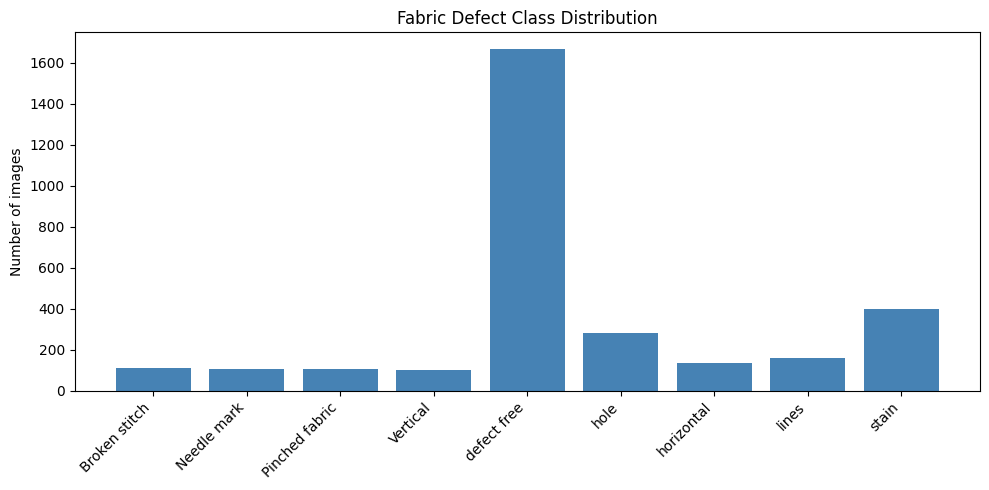

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.title("Fabric Defect Class Distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Display Sample Images

**What:** Show one random sample image from each class.

**Why:** Visual inspection builds intuition for how the defects actually look (e.g. how "Hole" differs from "Pinched Fabric" or "Needle Mark") and can surface labeling issues (mislabeled or ambiguous images) before we ever train a model.

**Observations:** _By Looking at these images i can see some of them seems are mislabeled. For example hole labeled image. I cannot see any hole there or in vertical labeled image_

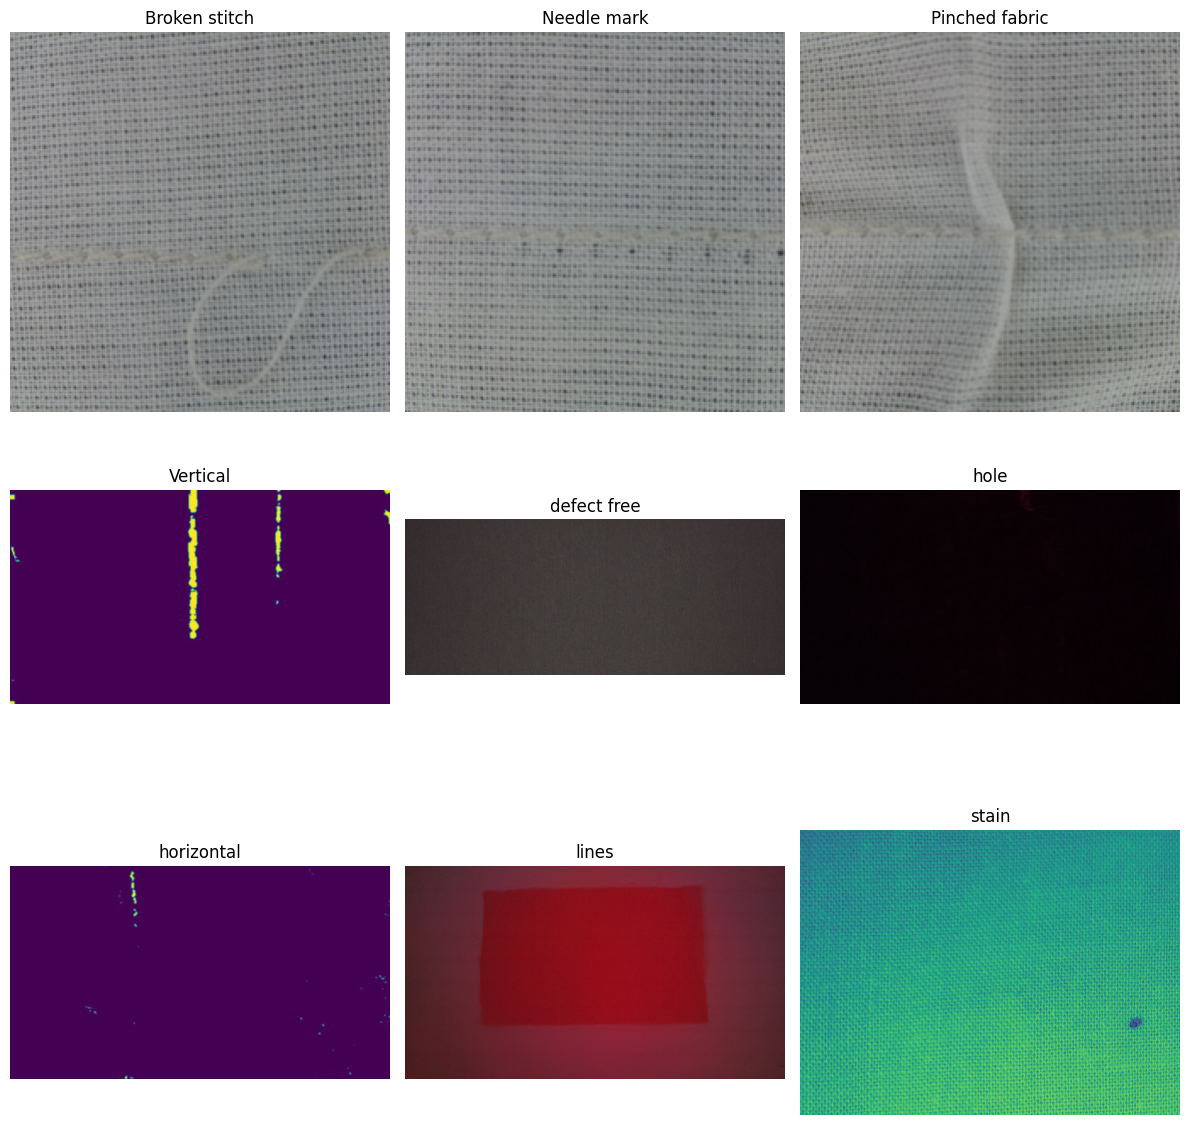

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, cls in zip(axes.flat, class_names):
    img_files = list((Path(ds2) / cls).glob("*"))
    sample_path = random.choice(img_files)
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Check Image Sizes

**What:** Measure the width and height of every image in the dataset.

**Why:** CNNs need a fixed input size. If images vary widely in resolution or aspect ratio, that shapes the resizing/cropping strategy in preprocessing and whether we risk distorting defect shapes.

**Observations:** _Image dimensions vary widely — width ranges from 201 to 4608px, height from 224 to 3456px. Only 13 unique sizes appear across 3067 images, so several images share the same resolution. This variability means all images will need to be resized to a consistent shape before feeding them into a CNN_

In [7]:
sizes = []
for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
        except Exception:
            pass

widths, heights = zip(*sizes)
print(f"Checked {len(sizes)} images")
print(f"Width  - min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.0f}")
print(f"Unique sizes: {len(set(sizes))}")

Checked 3067 images
Width  - min: 201, max: 4608, avg: 1866
Height - min: 224, max: 3456, avg: 891
Unique sizes: 13


## 8. Check File Formats

**What:** Inspect the file extensions and actual image formats (as reported by PIL) present in the dataset.

**Why:** Mixed formats (e.g. JPEG vs PNG vs BMP) can carry different color modes or compression artifacts, which affects how we build the data loader and whether format-specific preprocessing is needed.

**Observations:** _The dataset is almost entirely JPEG (2917 images, ~95%) with a small minority of PNG (150 images, ~5%)_

In [8]:
extensions = Counter()
formats = Counter()

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        extensions[img_path.suffix.lower()] += 1
        try:
            with Image.open(img_path) as img:
                formats[img.format] += 1
        except Exception:
            pass

print("File extensions:", dict(extensions))
print("PIL-detected formats:", dict(formats))

File extensions: {'.jpg': 2917, '.png': 150}
PIL-detected formats: {'JPEG': 2917, 'PNG': 150}


## 9. Check for Missing or Corrupted Images

**What:** Attempt to open every image file and flag any that fail to load or appear empty/zero-byte.

**Why:** A single corrupted file will crash training mid-epoch if it slips into a DataLoader. Catching this now means we can exclude or re-download bad files before training starts, rather than debugging a crash hours into a run.

**Observations:** _No missing or corrupted images were found (0 zero-byte files, 0 files that failed to open)._

In [9]:
corrupted = []
zero_byte = []

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        if img_path.stat().st_size == 0:
            zero_byte.append(img_path)
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append((img_path, str(e)))

print(f"Zero-byte files: {len(zero_byte)}")
print(f"Corrupted files: {len(corrupted)}")

for p in zero_byte:
    print(" [empty]    ", p)
for p, err in corrupted:
    print(" [corrupted]", p, "-", err)

Zero-byte files: 0
Corrupted files: 0


## 10. Summary

**Key findings from this exploration:**

- Total images: _3067_
- Number of classes: _9_
- Class balance: _imbalanced_
- Image dimensions: _variable_
- File formats: _mostly JPEG (95%), some PNG (5%)_
- Data quality: _no missing or corrupted files_

**Implications for preprocessing (Notebook 02):** _Resize/crop all images to a fixed size (e.g. 224×224) to match the CNN input requirements
- Convert all images to RGB to normalize PNG/JPEG differences
- Address class imbalance via weighted loss, oversampling minority classes, or targeted augmentation
- Manually review the flagged hole/vertical samples for potential mislabeling before training_